In [96]:
import plotly.io as pio

pio.renderers.default = 'notebook_connected+png'

import warnings
warnings.filterwarnings('ignore')

# E-commerce Business Transaction
#### Sales transaction of a UK-based e-commerce (online retail) for one year

## Introduction

This is a sales transaction data set of UK-based e-commerce (online retail) for one year. This London-based shop has been selling gifts and homewares for adults and children through the website since 2007. Their customers come from all over the world and usually make direct purchases for themselves. There are also small businesses that buy in bulk and sell to other customers through retail outlet channels.

The data set contains 500K rows and 8 columns. The following is the description of each column. There is a small percentage of order cancellation in the data set. Most of these cancellations were due to out-of-stock conditions on some products. Under this situation, customers tend to cancel an order as they want all products delivered all at once.

#### Goals
My main objective in throughout this project is to create well-separated customers segments that which the business can target with tailored marketing campaigns and strategies. My main focus will rely on data cleaning, feature engineering and feature selection, utilizing K-Means, HDBScan and other models to define segmentations. Use PCA and UMAP to discover the dataframe`s structure and to see if there is overall segmentation of the dataset.

#### Evaluation Framework (RFM)
To quantitatively measure and define these segments, the project will implement the RFM (Recency, Frequency, Monetary value) framework. This framework evaluates customer behavior based on three core dimensions derived from the dataset:
- Recency: how many days have passed since the last purchase from the most recent date in the dataset
- Frequency: how many times did the customer purchase in a single year
- Monetary value: the average amount of capital spent by the customer with a single transaction

# 1. Importing Libraries and Exploratory Data Analysis

### Importing libraries

In [97]:
import pandas as pd
import numpy as np
import seaborn as sns # visuals
import matplotlib.pyplot as plt # visuals
import plotly.express as px # interactive visualisation

### Explanatory Data Analysis
To get a general understanding of the data structure, missing values and statistics.

In [98]:
df = pd.read_csv("data/Sales Transaction v.4a.csv")

In [99]:
df.head(3)

,TransactionNo,Date,ProductNo,ProductName,Price,Quantity,CustomerNo,Country
0,581482,12/9/2019,22485,Set Of 2 Wooden Market Crates,21.47,12,17490.0,United Kingdom
1,581475,12/9/2019,22596,Christmas Star Wish List Chalkboard,10.65,36,13069.0,United Kingdom
2,581475,12/9/2019,23235,Storage Tin Vintage Leaf,11.53,12,13069.0,United Kingdom


In [100]:
df.isna().sum()

TransactionNo     0
Date              0
ProductNo         0
ProductName       0
Price             0
Quantity          0
CustomerNo       55
Country           0
dtype: int64

- Since there are missing valuess in the CustomerNo column I need to remove them.

In [101]:
df.describe()

,Price,Quantity,CustomerNo
count,536350.000000,536350.000000,536295.000000
mean,12.662182,9.919347,15227.893178
std,8.490450,216.662300,1716.582932
min,5.130000,-80995.000000,12004.000000
25%,10.990000,1.000000,13807.000000
50%,11.940000,3.000000,15152.000000
75%,14.090000,10.000000,16729.000000
max,660.620000,80995.000000,18287.000000


- Quantity has negative value which does not align with data integrity, inspect and remove if necessary. (It may be the returned articles.)

In [102]:
# checking the statistics of the object datatypes
df.describe(include="O")

,TransactionNo,Date,ProductNo,ProductName,Country
count,536350,536350,536350,536350,536350
unique,23204,305,3768,3768,38
top,573585,12/5/2019,85123A,Cream Hanging Heart T-Light Holder,United Kingdom
freq,1111,5299,2378,2378,485095


In [103]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 536350 entries, 0 to 536349
Data columns (total 8 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   TransactionNo  536350 non-null  str    
 1   Date           536350 non-null  str    
 2   ProductNo      536350 non-null  str    
 3   ProductName    536350 non-null  str    
 4   Price          536350 non-null  float64
 5   Quantity       536350 non-null  int64  
 6   CustomerNo     536295 non-null  float64
 7   Country        536350 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 32.7 MB


- change date to datetime
- check the integrity of features, does every record follow the pre-described pattern?

# 2. Data cleaning
Now I will inspect and fix the data integrity problems I found previously.

#### Convert date to datetime

In [104]:
df["Date"] = pd.to_datetime(df["Date"])

I converted the date into datetime datatype, before it was a normal string. With datetime datatype I can carry out calculations with dates, just like subtraction and addition to create frequency and recency features.

#### Removing NaN from CustomerNo

In [105]:
df[df["CustomerNo"].isna()].head()

,TransactionNo,Date,ProductNo,ProductName,Price,Quantity,CustomerNo,Country
6511,C581406,2019-12-08,46000M,Polyester Filler Pad 45x45cm,6.19,-240,NaN,United Kingdom
6512,C581406,2019-12-08,46000S,Polyester Filler Pad 40x40cm,6.19,-300,NaN,United Kingdom
90098,C575153,2019-11-08,22947,Wooden Advent Calendar Red,44.25,-1,NaN,United Kingdom
102671,C574288,2019-11-03,22178,Victorian Glass Hanging T-Light,25.37,-1,NaN,United Kingdom
117263,C573180,2019-10-28,23048,Set Of 10 Lanterns Fairy Light Star,14.50,-1,NaN,United Kingdom


In [106]:
df = df.dropna()

I dropped the records where CustomerNo is null, since I will group the records by that column to create individual groupped rows. If there is no customer to group by, then there is no reason to keep these records.

#### Removing cancelled transactions
Checking with regex syntax for cancelled orders.

In [107]:
df[~df["TransactionNo"].str.contains(r"[cC]")]

,TransactionNo,Date,ProductNo,ProductName,Price,Quantity,CustomerNo,Country
0,581482,2019-12-09,22485,Set Of 2 Wooden Market Crates,21.47,12,17490.0,United Kingdom
1,581475,2019-12-09,22596,Christmas Star Wish List Chalkboard,10.65,36,13069.0,United Kingdom
2,581475,2019-12-09,23235,Storage Tin Vintage Leaf,11.53,12,13069.0,United Kingdom
3,581475,2019-12-09,23272,Tree T-Light Holder Willie Winkie,10.65,12,13069.0,United Kingdom
4,581475,2019-12-09,23239,Set Of 4 Knick Knack Tins Poppies,11.94,6,13069.0,United Kingdom
...,...,...,...,...,...,...,...,...
536320,536585,2018-12-01,37449,Ceramic Cake Stand + Hanging Cakes,20.45,2,17460.0,United Kingdom
536321,536590,2018-12-01,22776,Sweetheart 3 Tier Cake Stand,20.45,1,13065.0,United Kingdom
536322,536590,2018-12-01,22622,Box Of Vintage Alphabet Blocks,20.45,2,13065.0,United Kingdom
536323,536591,2018-12-01,37449,Ceramic Cake Stand + Hanging Cakes,20.45,1,14606.0,United Kingdom


For TransactionNo column, the pattern for the instances are 6 digits. If there is a C in front that indicates cancellation. Since these records are not ended up as sold I must find the pair and remove them.

In [108]:
df["AbsQuantity"] = df["Quantity"].abs()

# sort, so we remove the previous transaction from the dataframe
df = df.sort_values(by=["CustomerNo", "ProductNo", "Date"]).reset_index(drop=True)

# creating different dfs
pos_df = df[df["Quantity"] > 0].copy()
neg_df = df[df["Quantity"] < 0].copy()


pos_df["Pair_ID"] = pos_df.groupby(["CustomerNo", "ProductNo", "Price", "AbsQuantity"]).cumcount() # creates positive transaction 0,1,2,3
neg_df["Pair_ID"] = neg_df.groupby(["CustomerNo", "ProductNo", "Price", "AbsQuantity"]).cumcount() # creates negative transactions with 0,1,2 to help with merge


# this dataframe represent the transactions that were first bought then returned. so there is no profit from these
cancelled_pairs = pos_df.merge(
    neg_df[["CustomerNo", "ProductNo", "Price", "AbsQuantity", "Pair_ID"]],
    on=["CustomerNo", "ProductNo", "Price", "AbsQuantity", "Pair_ID"],
    how="inner"
)

pos_rows_to_drop = pos_df[
    pos_df.set_index(["CustomerNo", "ProductNo", "Price", "AbsQuantity", "Pair_ID"]).index.isin(
        cancelled_pairs.set_index(["CustomerNo", "ProductNo", "Price", "AbsQuantity", "Pair_ID"]).index
    )
].index


neg_rows_to_drop = neg_df.index

df_clean = df.drop(index=set(neg_rows_to_drop).union(set(pos_rows_to_drop)))
df_clean = df_clean.drop(columns=["AbsQuantity"])

In [109]:
print("Dirty df length",len(df),"\n","Clean df length",len(df_clean))

Dirty df length 536295 
 Clean df length 524915


The cancelled pairs were removed, as well as negative transactions. There are no more cancellations in the dataframe which would disturb the clustering analysis.

#### Feature integrity
Here I check with regex syntax, whether all the instances for a column follows the same pattern.

In [110]:
df_clean.info()

<class 'pandas.DataFrame'>
Index: 524915 entries, 0 to 536294
Data columns (total 8 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   TransactionNo  524915 non-null  str           
 1   Date           524915 non-null  datetime64[us]
 2   ProductNo      524915 non-null  str           
 3   ProductName    524915 non-null  str           
 4   Price          524915 non-null  float64       
 5   Quantity       524915 non-null  int64         
 6   CustomerNo     524915 non-null  float64       
 7   Country        524915 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), str(4)
memory usage: 36.0 MB


In [111]:
# there are no letters in TransactionNo
df_clean[df_clean["TransactionNo"].str.contains(r"[a-zA-Z]")]

,TransactionNo,Date,ProductNo,ProductName,Price,Quantity,CustomerNo,Country


In [112]:
# every record in the transactionNo follow the 6 digit number rule
df_clean[~df_clean["TransactionNo"].str.contains(r"^\d{6}$")]

,TransactionNo,Date,ProductNo,ProductName,Price,Quantity,CustomerNo,Country


In [113]:
# date follows the "yyyy-mm-dd" format for all the records
df_clean[~df_clean["Date"].astype(str).str.contains(r"^\d{4}\-\d{2}\-\d{2}$")]

,TransactionNo,Date,ProductNo,ProductName,Price,Quantity,CustomerNo,Country


In [114]:
print("Earliest date", df_clean["Date"].min(), "\n","Latest date",df_clean["Date"].max())

Earliest date 2018-12-01 00:00:00 
 Latest date 2019-12-09 00:00:00


In [115]:
# this feature is all aligned. either 5 or 6 digits with a single letter
df_clean[df_clean["ProductNo"].str.contains(r"^[a-zA-Z]")]

,TransactionNo,Date,ProductNo,ProductName,Price,Quantity,CustomerNo,Country


In [116]:
# no negative prices
df_clean[df_clean["Price"] < 0]

,TransactionNo,Date,ProductNo,ProductName,Price,Quantity,CustomerNo,Country


In [117]:
# no negative quantity
df_clean[df_clean["Quantity"] < 0]

,TransactionNo,Date,ProductNo,ProductName,Price,Quantity,CustomerNo,Country


In [118]:
# customerNo is aligned, does not contain letters
df_clean[df_clean["CustomerNo"].astype(str).str.contains(r"[a-zA-Z]")]

,TransactionNo,Date,ProductNo,ProductName,Price,Quantity,CustomerNo,Country


In [119]:
# country clean, does not contain numbers
df_clean[~df_clean["Country"].astype(str).str.contains(r"[a-zA-Z]")]

,TransactionNo,Date,ProductNo,ProductName,Price,Quantity,CustomerNo,Country


#### Splitting dataframe by countries

In [120]:
uk_df = df_clean[df_clean["Country"] == "United Kingdom"].copy()
de_df = df_clean[df_clean["Country"] == "Germany"].copy()
fr_df = df_clean[df_clean["Country"] == "France"].copy()

# 3. Customer Segments for United Kingdom

The reason why I only chose United Kingdom as my area if interest is because it is the only country where there are enough records, 4295 to be specific, which are meaningful for the clustering. Germany and France have less than a hundred individually.

In [121]:
print("UK has",uk_df["CustomerNo"].nunique(),"unique customers")
print("Germany has",de_df["CustomerNo"].nunique(),"unique customers")
print("France has",fr_df["CustomerNo"].nunique(),"unique customers")

UK has 4295 unique customers
Germany has 91 unique customers
France has 87 unique customers


### Feature engineering

I will extract the feauters used for RFM analysis.
- Receny: how long was the last purchase (in days)
- Frequency: in the given timewindow how many times did the customer order
- Monetary value: how much the customer spent in this time window

In [122]:
max_date_uk = uk_df["Date"].max()

In [123]:
uk_df["Value"] = uk_df["Quantity"] * uk_df["Price"]
uk_df.head()

,TransactionNo,Date,ProductNo,ProductName,Price,Quantity,CustomerNo,Country,Value
0,551004,2019-04-26,20676,Red Retrospot Bowl,12.77,1,12004.0,United Kingdom,12.77
1,551004,2019-04-26,20712,Jumbo Bag Woodland Animals,7.24,1,12004.0,United Kingdom,7.24
2,551004,2019-04-26,20717,Strawberry Shopper Bag,12.77,1,12004.0,United Kingdom,12.77
3,551004,2019-04-26,20828,Glitter Butterfly Clips,15.33,1,12004.0,United Kingdom,15.33
4,551004,2019-04-26,21086,Set/6 Red Spotty Paper Cups,11.92,4,12004.0,United Kingdom,47.68


In [124]:
rfm_uk = uk_df.groupby("CustomerNo").agg({
    "Date" : lambda x: (max_date_uk - x.max()).days,
    "TransactionNo" : "nunique",
    "Value" : "sum"
})

In [125]:
rfm_uk.columns = ["Recency", "Frequency", "Monetary"]
rfm_uk["Avg_Basket_Value"] = rfm_uk["Monetary"] / rfm_uk["Frequency"]
rfm_uk

,Recency,Frequency,Monetary,Avg_Basket_Value
CustomerNo,,,,
12004.0,227,1,1509.60,1509.600000
12006.0,218,1,24.76,24.760000
12008.0,276,1,5689.57,5689.570000
12013.0,359,1,69.96,69.960000
12024.0,176,1,149.52,149.520000
...,...,...,...,...
18280.0,277,1,623.26,623.260000
18281.0,180,1,576.58,576.580000
18282.0,7,2,1044.86,522.430000


Now I have a dataframe containing the records of individual customers and their transaction history. For customer 12004, the last purchase was 227 days ago, with being this the first transaction, spending 1509 sterling pounds.

### Outliers

Since outliers tend to distort the balance of the dataframe I will separate them as the last step of the data cleaning. I specifically left the outliers for each subgroup so the country`s statistical attributes apply to these subgroups and not the general attributes.

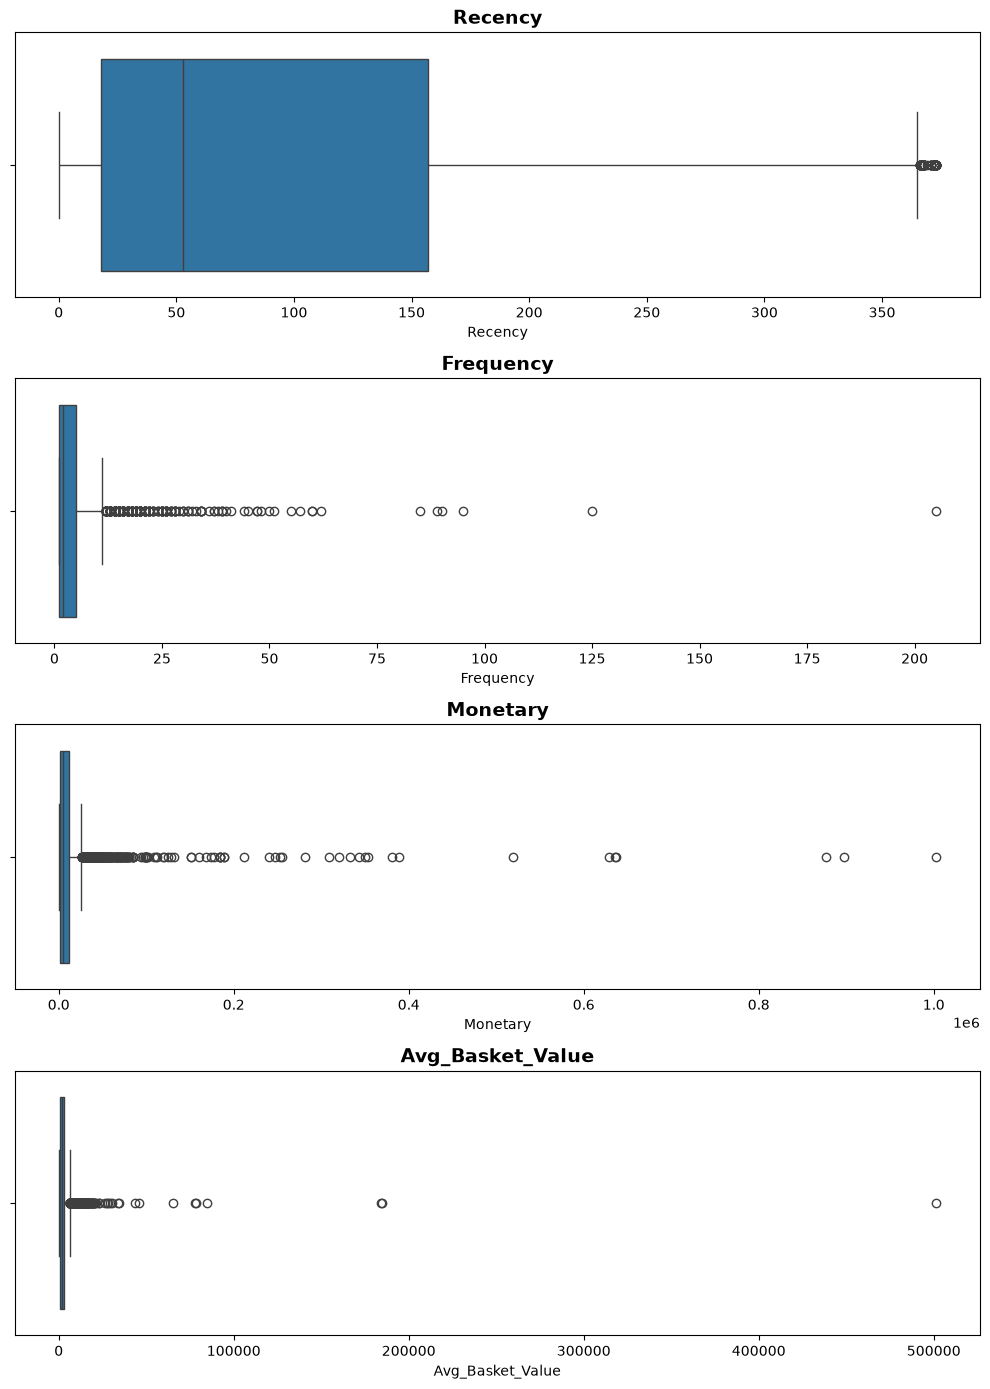

In [126]:
plt.figure(figsize=(10, 14))


plt.subplot(4, 1, 1)
sns.boxplot(x=rfm_uk["Recency"])
plt.title("Recency", fontsize=14, fontweight='bold')


plt.subplot(4, 1, 2)
sns.boxplot(x=rfm_uk["Frequency"])
plt.title("Frequency", fontsize=14, fontweight='bold')

plt.subplot(4, 1, 3)
sns.boxplot(x=rfm_uk["Monetary"])
plt.title("Monetary", fontsize=14, fontweight='bold')

plt.subplot(4, 1, 4)
sns.boxplot(x=rfm_uk["Avg_Basket_Value"])
plt.title("Avg_Basket_Value", fontsize=14, fontweight='bold')


plt.tight_layout()
plt.show()

Recency looks fine, I will not touch it. However the rest are heavily skewed, cleaning outliers is mandatory.

In [127]:
outlier_indices = set()

features = ["Recency", "Frequency", "Monetary"]

for col in features:
    Q1 = rfm_uk[col].quantile(0.25)
    Q3 = rfm_uk[col].quantile(0.75)
    iqr = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * iqr
    upper_bound = Q3 + 1.5 * iqr
    
    bad_rows = rfm_uk[(rfm_uk[col] < lower_bound) | (rfm_uk[col] > upper_bound)].index
    

    outlier_indices = outlier_indices.union(set(bad_rows))


rfm_uk_clean = rfm_uk.drop(index=outlier_indices)
rfm_uk_outliers = rfm_uk.loc[list(outlier_indices)]

To filter the outliers, I used the interquantile range method. Anything that is more than 1.5*IQR away from Q3 or below Q1 counts as outlier, this method is simple to use and easy to understand. There are other methods like using Z-score which is based on standard deviation and mean of the instances, or applying algorithms that identifies outliers. (HDBSCAN or IsolationForest)

In [128]:
rfm_uk_clean.head()

,Recency,Frequency,Monetary,Avg_Basket_Value
CustomerNo,,,,
12004.0,227,1,1509.60,1509.60
12006.0,218,1,24.76,24.76
12008.0,276,1,5689.57,5689.57
12013.0,359,1,69.96,69.96
12024.0,176,1,149.52,149.52


In [129]:
rfm_uk_outliers.head()

,Recency,Frequency,Monetary,Avg_Basket_Value
CustomerNo,,,,
16393.0,2,13,14575.21,1121.170000
16394.0,56,5,28134.87,5626.974000
14351.0,164,2,35208.91,17604.455000
16401.0,1,12,36723.86,3060.321667
14365.0,25,1,184148.76,184148.760000


Perfect, now I have created two subgroups of the UK dataframe, one contains the regular customers and the other the outier or the unusual customers. It is precious to keep these outliers, since they are the most valuable customers. They spend the most, spend most frequently, have the highest average basket value if they were outliers on the upper side of the boxplot.

### Visualization

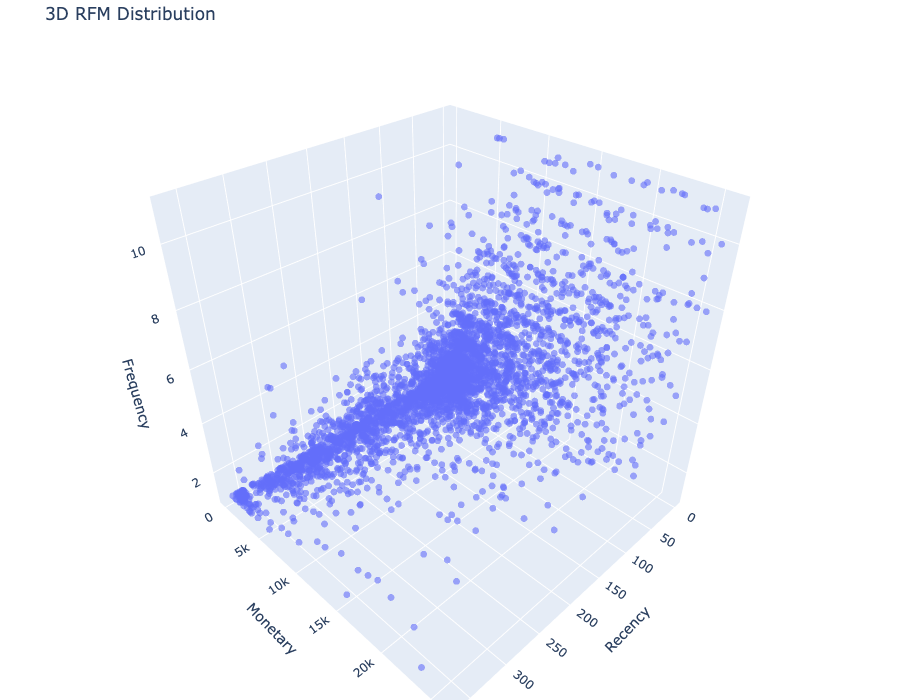

In [130]:
fig = px.scatter_3d(
    rfm_uk_clean,
    x="Recency",
    y="Monetary",
    z="Frequency",
    opacity=0.6,  
    title="3D RFM Distribution",
    labels={
        "Recency": "Recency (in days)",
        "Monetary": "Total spent",
        "Frequency": "Frequency",
    },
)

fig.update_traces(marker=dict(size=4))

fig.update_layout(
    width=900,
    height=700,
    margin=dict(l=0, r=0, b=0, t=40),  
    scene=dict(
        xaxis_title="Recency", yaxis_title="Monetary", zaxis_title="Frequency"
    ),
)

fig.show()

Every point on this plot represents a unique customer in the United Kingdom zone. There are points almost anywhere which implies customer diversity. Identifying clusters will help the marketing department tailor specific strategies to each group.

Also there is a positive correlation with frequency and monetary value, which is a no brainer, a customer who spends regurarly spends more in total.

## Creating clusters for normal customers

First and foremost, standardizing the data is crucial for the KMeans algorithm I will use. Without this step the features would be on different scale (elongated in one axis and crushed in the other), and the model would fail to converge to a meaningful optimum.

In [131]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

rfm_uk_clean_scaled = pd.DataFrame(scaler.fit_transform(rfm_uk_clean), columns=["Recency", "Frequency", "Monetary", "Avg_Basket_Value"], index=rfm_uk_clean.index)

One tricky part of the Kmeans algorithm is that it requires the number of clusters before the training. But how would I know this number? To find the best number of clusters I use silhouette scores and elbow method, and my personal opinion on the clusters.

This algorithm then takes the number of clusters n, and omits n points onto the higher dimension field. These points are omitted randomly and are bad initial guesses of the cluster centers. Then the model iteratively adjusts the centers` position until the average distances are minimized within clusters. Then repeat this multiple times to avoid settling in a local minimum. (n_init=10)

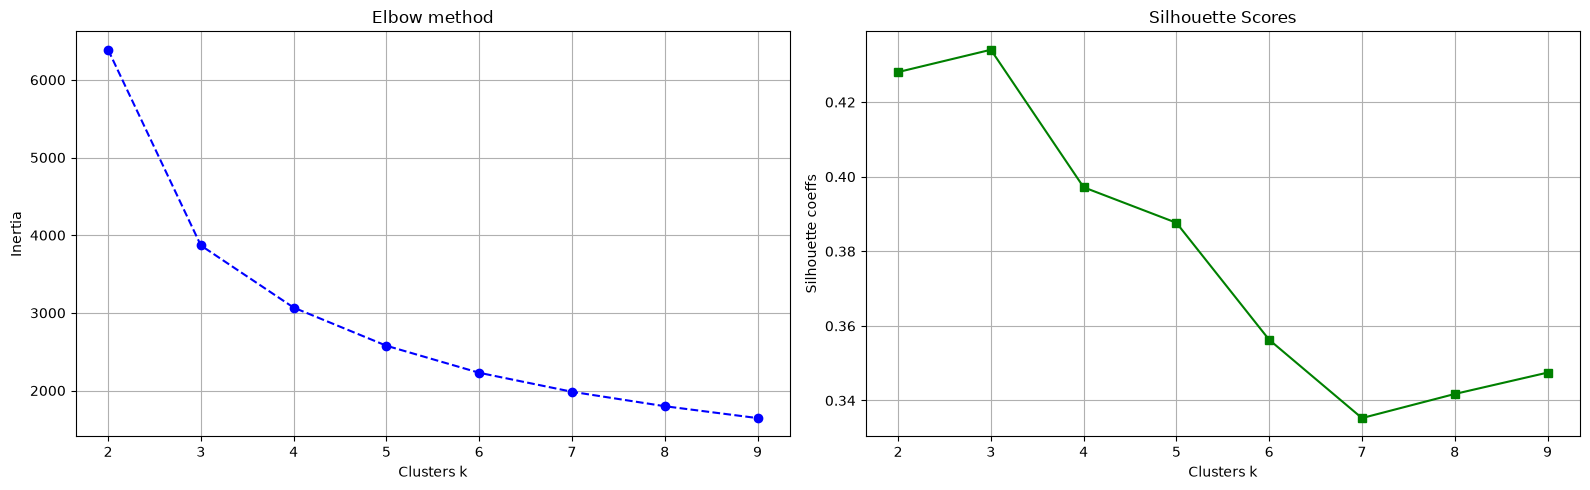

In [132]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.metrics import davies_bouldin_score


inertia = []
silhouette_scores = []
db_scores = []
k_range = range(2, 10)

features = ["Recency", "Frequency", "Monetary"]


for k in k_range:
    kmeans = KMeans(n_clusters=k, init="k-means++", random_state=11, n_init=10)
    kmeans.fit(rfm_uk_clean_scaled[features])

    inertia.append(kmeans.inertia_)
    
    score = silhouette_score(rfm_uk_clean_scaled[features], kmeans.labels_, random_state=11)
    silhouette_scores.append(score)

    labels = kmeans.fit_predict(rfm_uk_clean_scaled[features])

    db_score = davies_bouldin_score(rfm_uk_clean_scaled, labels)
    db_scores.append(db_score)


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))


ax1.plot(k_range, inertia, marker="o", linestyle="--", color="b")
ax1.set_title("Elbow method")
ax1.set_xlabel("Clusters k")
ax1.set_ylabel("Inertia")
ax1.set_xticks(k_range)
ax1.grid(True)


ax2.plot(k_range, silhouette_scores, marker="s", linestyle="-", color="g")
ax2.set_title("Silhouette Scores")
ax2.set_xlabel("Clusters k")
ax2.set_ylabel("Silhouette coeffs")
ax2.set_xticks(k_range)
ax2.grid(True)

plt.tight_layout()
plt.show()

Altough, the elbow formed at k=4 clusters, and silhouette score peaks at 4 clusters I found that 7 clusters gave much more meaning in the 3d scatterplot. Low number of clusters only answer simple questions and straighforward, like spend a lot or not.

In [133]:
features = ["Recency", "Frequency", "Monetary"]

final_kmeans = KMeans(n_clusters=7, init="k-means++", random_state=11, n_init=10)
cluster_labels = final_kmeans.fit_predict(rfm_uk_clean_scaled[features])

rfm_uk_clean["Cluster"] = cluster_labels.astype(str)

rfm_uk_clean.head()

,Recency,Frequency,Monetary,Avg_Basket_Value,Cluster
CustomerNo,,,,,
12004.0,227,1,1509.60,1509.60,3
12006.0,218,1,24.76,24.76,0
12008.0,276,1,5689.57,5689.57,3
12013.0,359,1,69.96,69.96,3
12024.0,176,1,149.52,149.52,0


Above I used the KMeans with 7 clusters to find the customer segments, then assigned each customer to the their cluster.

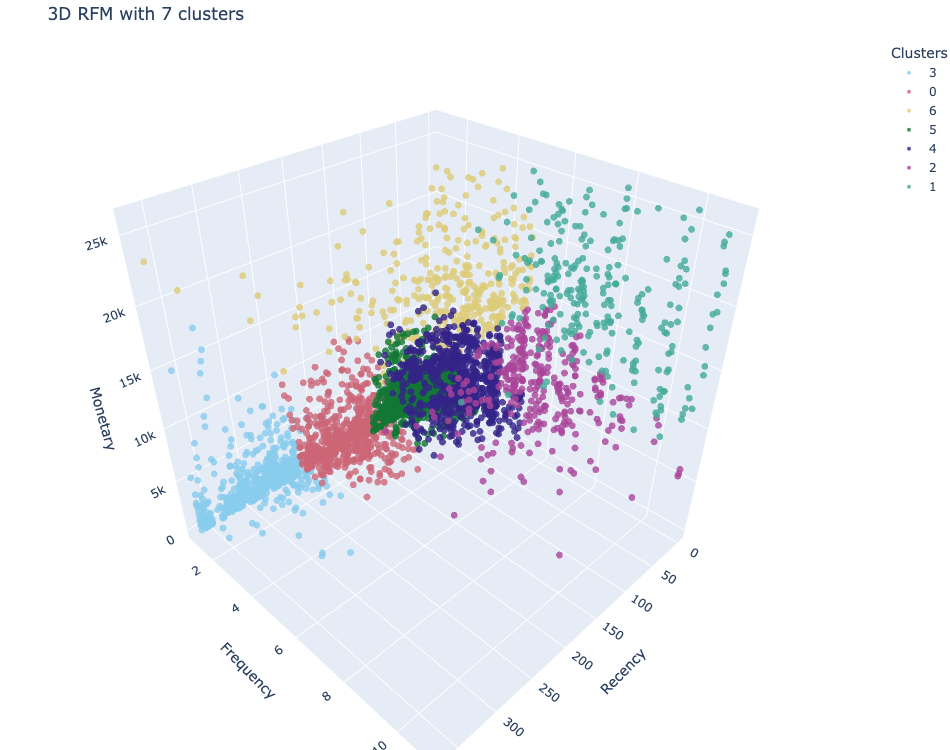

In [134]:
fig = px.scatter_3d(
    rfm_uk_clean,
    x="Recency",
    y="Frequency",
    z="Monetary",
    color="Cluster", 
    opacity=0.8,
    title="3D RFM with 7 clusters",
    labels={
        "Recency": "Recency (days)",
        "Frequency": "Frequency",
        "Monetary": "Monetary",
        "Cluster": "Clusters"
    },
    color_discrete_sequence=px.colors.qualitative.Safe 
)

fig.update_traces(marker=dict(size=4))


fig.update_layout(
    width=950,
    height=750,
    margin=dict(l=0, r=0, b=0, t=40),
    scene=dict(
        xaxis_title="Recency",
        yaxis_title="Frequency",
        zaxis_title="Monetary"
    )
)

fig.show()

Now these clusters look much more meaningful, and tell much more about the retail store`s customer base. I can see top spenders in yellow and turquise, and lost customers in light blue. Now that I have these clusters, I need to create a description about each one of them, how many customers there are, what are the statistics within the clusters. This helps identying and describing the customer segments.

In [135]:
# creating an aggregated dataframe with the help of clusters

uk_clean_comparison = rfm_uk_clean.groupby("Cluster").agg({
    "Recency": "mean",      
    "Frequency": "mean",    
    "Monetary": "mean",    
    "Cluster": "count"      
})

uk_clean_comparison.columns = [
    "Average_Recency", 
    "Average_Frequency", 
    "Average_Monetary", 
    "Customer_Count"
]

In [136]:
uk_clean_comparison.sort_values(by=["Average_Monetary","Average_Recency"], ascending=False)

,Average_Recency,Average_Frequency,Average_Monetary,Customer_Count
Cluster,,,,
1,27.324111,8.015810,18381.808300,253
6,66.374663,3.301887,15433.557655,371
2,34.326087,6.301242,8988.898758,322
4,42.916324,3.244170,5929.195926,729
0,174.774194,1.670968,3002.651226,620
5,43.738997,1.460594,2317.001934,977
3,290.384758,1.247212,2236.011022,538


# Targeting Strategy for Normal Customer Base

### Cluster 1 (Turquoise) - Champions
- Customer Count : 253
- Avg. Recency : 27 Days
- Avg. Frequency : 8.0 Purchases
- Avg. Monetary : $18,382

Strategy : Highest value, lowest recency. Reward them, offer early access to new products.

### Cluster 6 (Yellow) - Big Spenders
- Customer Count : 371
- Avg. Recency : 66 Days
- Avg. Frequency : 3.3 Purchases
- Avg. Monetary : $15,434

Strategy : High ticket value per purchase, but buy less often. Upsell high-margin items.

### Cluster 2 (Purple) - Loyal customers
- Customer Count : 322
- Avg. Recency : 34 Days
- Avg. Frequency : 6.3 Purchases
- Avg. Monetary : $8,989

Strategy : Buy frequently and recently. Excellent target for loyalty programs.

### Cluster 4 (Dark Blue) Regulars
- Customer Count : 729
- Avg. Recency : 43 Days
- Avg. Frequency : 3.2 Purchases
- Avg. Monetary : $5,929

Strategy : The reliable core customer base. Send standard promotional emails.

### Cluster 0 (Peach) Customers At Risk
- Customer Count : 620
- Avg. Recency : 175 Days
- Avg. Frequency : 1.7 Purchases
- Avg. Monetary : $3,003

Strategy : Used to purchase, starting to vanish. Need targeted "We miss you" win-back campaigns.

### Cluster 5 (Green) New Customers
- Customer Count : 977
- Avg. Recency : 44 Days
- Avg. Frequency : 1.5 Purchases
- Avg. Monetary : $2,317

Strategy : Largest segment count wise. Bought recently but haven't spent much yet. Send welcome emails and satisfaction surveys.

### Cluster 3 (Light Blue) Lost Customers
- Customer Count : 538
- Avg. Recency : 290 Days
- Avg. Frequency : 1.2 Purchases
- Avg. Monetary : $2,236

Strategy : Likely one-time buyers (for example BBQ grill). Ignore or send major clearance sales only.

## Clustering on the outlier subset

For exceptional customers I used the same technique as for the normal ones. However, now I used the number of clusters that scored the best on silhouette score which is 4.

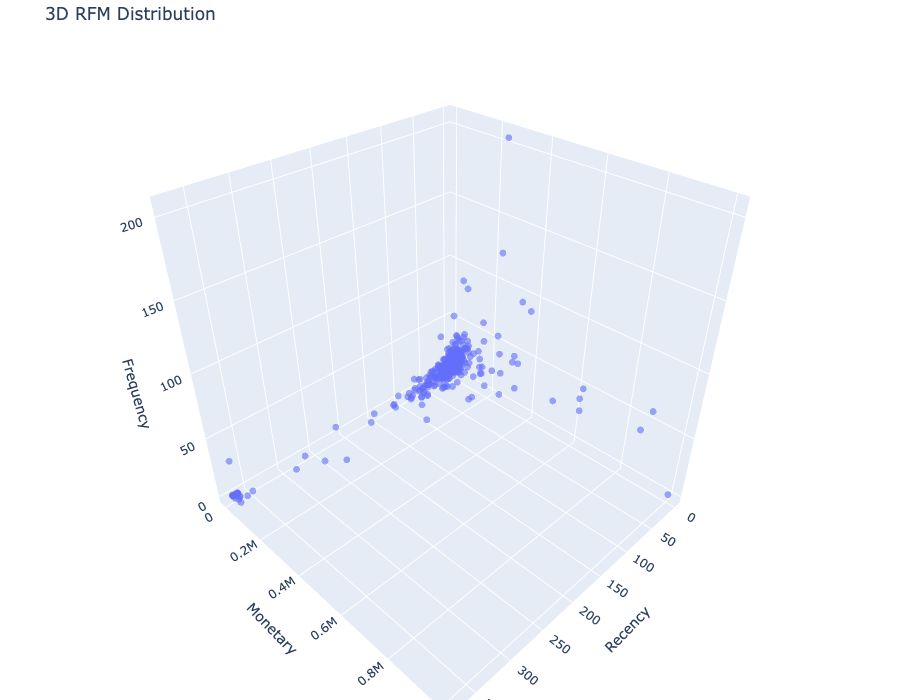

In [137]:
fig = px.scatter_3d(
    rfm_uk_outliers,
    x="Recency",
    y="Monetary",
    z="Frequency",
    opacity=0.6,  
    title="3D RFM Distribution",
    labels={
        "Recency": "Recency (in days)",
        "Monetary": "Total spent",
        "Frequency": "Frequency",
    },
)

fig.update_traces(marker=dict(size=4))

fig.update_layout(
    width=900,
    height=700,
    margin=dict(l=0, r=0, b=0, t=40),  
    scene=dict(
        xaxis_title="Recency", yaxis_title="Monetary", zaxis_title="Frequency"
    ),
)

fig.show()

Scaling just like before, to maintain data integrity.

In [138]:
rfm_uk_outliers_scaled = pd.DataFrame(scaler.fit_transform(rfm_uk_outliers), columns=["Recency", "Frequency", "Monetary", "Avg_Basket_Value"], index=rfm_uk_outliers.index)

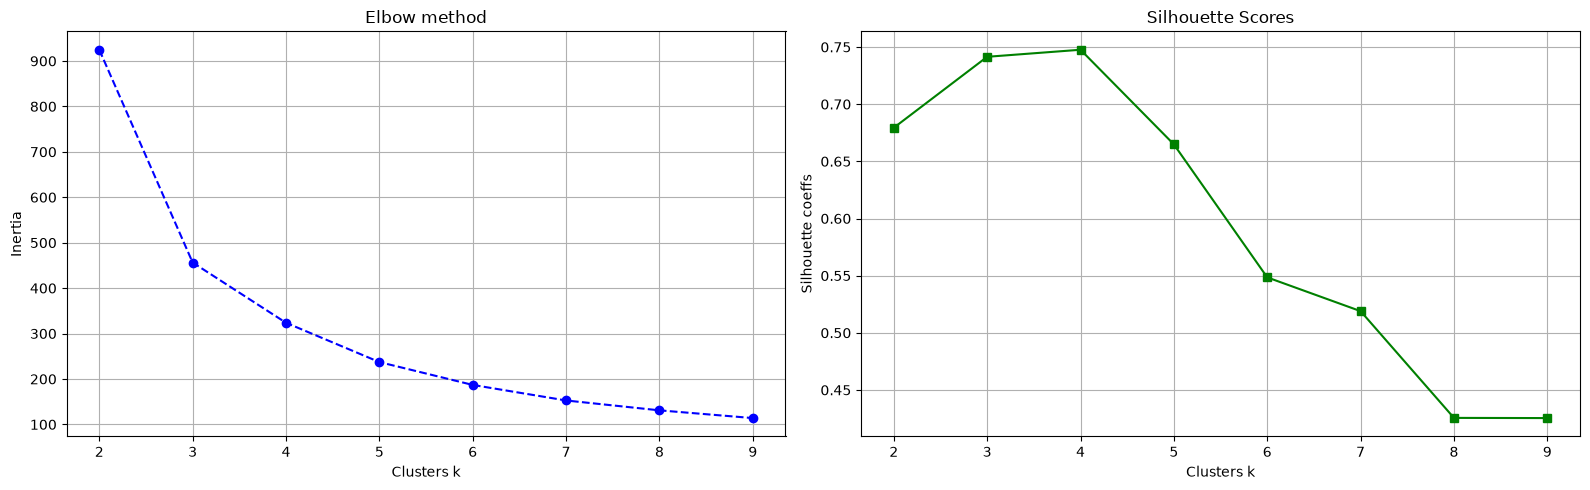

In [139]:
inertia = []
silhouette_scores = []
k_range = range(2, 10)

features = ["Recency", "Frequency", "Monetary"]


for k in k_range:
    kmeans = KMeans(n_clusters=k, init="k-means++", random_state=11, n_init=10)
    kmeans.fit(rfm_uk_outliers_scaled[features])

    inertia.append(kmeans.inertia_)
    
    score = silhouette_score(rfm_uk_outliers_scaled[features], kmeans.labels_, random_state=11)
    silhouette_scores.append(score)


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))


ax1.plot(k_range, inertia, marker="o", linestyle="--", color="b")
ax1.set_title("Elbow method")
ax1.set_xlabel("Clusters k")
ax1.set_ylabel("Inertia")
ax1.set_xticks(k_range)
ax1.grid(True)


ax2.plot(k_range, silhouette_scores, marker="s", linestyle="-", color="g")
ax2.set_title("Silhouette Scores")
ax2.set_xlabel("Clusters k")
ax2.set_ylabel("Silhouette coeffs")
ax2.set_xticks(k_range)
ax2.grid(True)

plt.tight_layout()
plt.show()

The inertia and silhouette scores reveal that cluster 4 is the best on the outlier subset.

In [140]:
features = ["Recency", "Frequency", "Monetary"]

final_kmeans = KMeans(n_clusters=4, init="k-means++", random_state=11, n_init=10)
cluster_labels = final_kmeans.fit_predict(rfm_uk_outliers_scaled[features])

rfm_uk_outliers["Cluster"] = cluster_labels.astype(str)

rfm_uk_outliers.head() 

,Recency,Frequency,Monetary,Avg_Basket_Value,Cluster
CustomerNo,,,,,
16393.0,2,13,14575.21,1121.170000,0
16394.0,56,5,28134.87,5626.974000,0
14351.0,164,2,35208.91,17604.455000,0
16401.0,1,12,36723.86,3060.321667,0
14365.0,25,1,184148.76,184148.760000,0


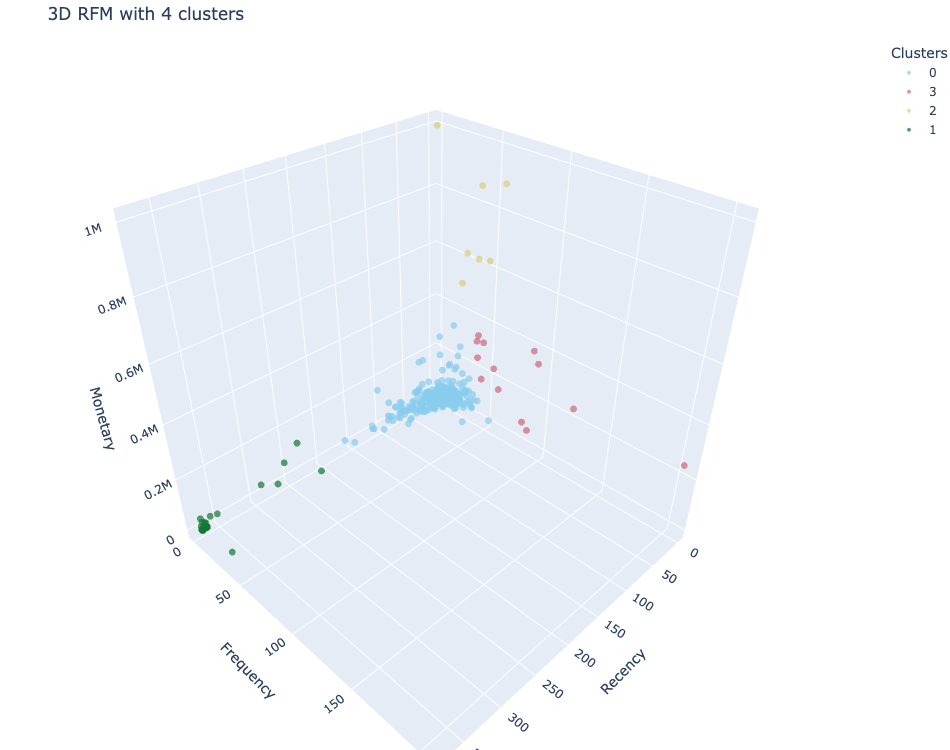

In [141]:
fig = px.scatter_3d(
    rfm_uk_outliers,
    x="Recency",
    y="Frequency",
    z="Monetary",
    color="Cluster", 
    opacity=0.7,
    title="3D RFM with 4 clusters",
    labels={
        "Recency": "Recency (days)",
        "Frequency": "Frequency",
        "Monetary": "Monetary",
        "Cluster": "Clusters"
    },
    color_discrete_sequence=px.colors.qualitative.Safe 
)

fig.update_traces(marker=dict(size=4))


fig.update_layout(
    width=950,
    height=750,
    margin=dict(l=0, r=0, b=0, t=40),
    scene=dict(
        xaxis_title="Recency",
        yaxis_title="Frequency",
        zaxis_title="Monetary"
    )
)

fig.show()

In [142]:
uk_outliers_comparison = rfm_uk_outliers.groupby("Cluster").agg({
    "Recency" : "mean",
    "Frequency" : "mean",
    "Monetary" : "mean",
    "Cluster" : "count"
})
uk_outliers_comparison.columns =[
    "Average_Recency", 
    "Average_Frequency", 
    "Average_Monetary", 
    "Customer_Count"
]

In [143]:
uk_outliers_comparison.sort_values(by=["Average_Monetary", "Average_Frequency"], ascending=False)

,Average_Recency,Average_Frequency,Average_Monetary,Customer_Count
Cluster,,,,
2,3.571429,37.285714,742595.491429,7
3,5.461538,81.076923,261966.932308,13
0,19.858942,14.047859,47499.976448,397
1,361.161765,1.779412,8908.855588,68


# Targeting Strategy for Exceptional Customers

### Cluster 3 - The Whales
- Customer Count: 7 
- Avg. Recency: 24 Days
- Avg. Frequency: 37 purchases
- Avg. Monetary: $742,595

Strategy: Your absolute biggest buyers. They spend three-quarters of a million on average and buy almost every week. Assign dedicated account managers and offer exclusive partnership contracts.

### Cluster 2 - High-Frequency Partners
- Customer Count: 13
- Avg. Recency: 35 Days
- Avg. Frequency: 81 purchases
- Avg. Monetary: $261,967

Strategy: The most frequent buyers by far (ordering 81 times). They rely on supply chain constantly. Focus on logistical perfection, automated ordering, and volume discounts to keep them locked in.

### Cluster 1 - VIP Core
- Customer Count: 397
- Avg. Recency: 20 Days
- Avg. Frequency: 14 purchases
- Avg. Monetary: $47,500

Strategy: The backbone of high-volume revenue. They are extremely active (purchased just 20 days ago) and spend heavily. Invite them to premium loyalty tiers and B2B networking events.

### Cluster 0 - Lost Spenders
- Customer Count: 68
- Avg. Recency: 361 Days
- Avg. Frequency: 2 purchases
- Avg. Monetary: $8,909

Strategy: High average order value per purchase ($4,450 per order), but they haven't bought anything in a whole year. Contact them directly to find out why they flew away.